# PINN Solving Inverse 1D Burgers Equation (PyTorch): estimating kinematic viscosity

This notebook solves the inverse Burgers equation using a Physics-Informed Neural Network to estimate the kinematic viscosity (or diffusion coefficient).

## Burgers' Equation

We consider the one-dimensional viscous Burgers' equation

$$
\frac{\partial u}{\partial t}
+
u\frac{\partial u}{\partial x}
=
\nu\frac{\partial^2 u}{\partial x^2},
\qquad
x\in[-1,1],\;
t\in[0,1],
$$

where

- $u(x,t)$ is the velocity field,
- $\nu$ is the kinematic viscosity (unknown for the inverse problem).

### Initial Condition

The initial condition is

$$
u(x,0) = -\sin(\pi x),
\qquad
-1 \le x \le 1.
$$

### Boundary Conditions

Homogeneous Dirichlet boundary conditions are imposed at both ends of the domain,

$$
u(-1,t)=0,
\qquad
u(1,t)=0,
\qquad
0 \le t \le 1.
$$

### Objective

The goal of the inverse problem is to simultaneously learn

- the solution $u(x,t)$, and
- the unknown viscosity coefficient $\nu$

from sparse measurements while enforcing the Burgers' equation through the physics-informed neural network (PINN).

# Analytical Solution via the Hopf–Cole Transformation

https://en.wikipedia.org/wiki/Burgers%27_equation

To generate the synthetic training data, we compute the analytical solution of Burgers' equation using the **Hopf–Cole transformation**. This transformation converts the nonlinear Burgers' equation into the linear heat equation, which has a known integral solution.

## Hopf–Cole Transformation

Introduce a new function $\phi(x,t)$ such that

$$
u(x,t)=-2\nu\frac{\partial}{\partial x}\ln\phi(x,t)
=-2\nu\frac{\phi_x}{\phi}.
$$

Substituting this expression into Burgers' equation,

$$
u_t+u\,u_x=\nu u_{xx},
$$

shows that $\phi(x,t)$ satisfies the one-dimensional heat equation

$$
\phi_t=\nu\phi_{xx}.
$$

The solution can therefore be written as a convolution with the Gaussian heat kernel.

## Analytical Solution

For the initial condition

$$
u(x,0)=-\sin(\pi x),
$$

the Hopf–Cole solution is

$$
u(x,t)=
-\frac{
\displaystyle
\int_{-\infty}^{\infty}
\sin\!\left(\pi(x-\eta)\right)
\exp\!\left[
-\frac{\cos\!\left(\pi(x-\eta)\right)}
{2\pi\nu}
-\frac{\eta^2}{4\nu t}
\right]
d\eta
}
{
\displaystyle
\int_{-\infty}^{\infty}
\exp\!\left[
-\frac{\cos\!\left(\pi(x-\eta)\right)}
{2\pi\nu}
-\frac{\eta^2}{4\nu t}
\right]
d\eta
}.
$$

## Change of Variables

Introduce

$$
\eta=2\sqrt{\nu t}\,q,
$$

so that

$$
d\eta=2\sqrt{\nu t}\,dq,
$$

and

$$
\frac{\eta^2}{4\nu t}=q^2.
$$

The solution becomes

$$
u(x,t)=
-\frac{
\displaystyle
\int_{-\infty}^{\infty}
2\sqrt{\nu t}\,
\sin\!\left(\pi(x-cq)\right)
\exp\!\left(
-\frac{\cos(\pi(x-cq))}{2\pi\nu}
\right)
e^{-q^2}\,dq
}{
\displaystyle
\int_{-\infty}^{\infty}
2\sqrt{\nu t}\,
\exp\!\left(
-\frac{\cos(\pi(x-cq))}{2\pi\nu}
\right)
e^{-q^2}\,dq
},
$$

where

$$
c=2\sqrt{\nu t}.
$$

## Gauss–Hermite Quadrature

Since both integrals have the form

$$
\int_{-\infty}^{\infty}
e^{-q^2}f(q)\,dq,
$$

they can be accurately approximated using Gauss–Hermite quadrature,

$$
\int_{-\infty}^{\infty}
e^{-q^2}f(q)\,dq
\approx
\sum_{i=1}^{N_q}w_i\,f(q_i),
$$

where

- $q_i$ are the Gauss–Hermite quadrature nodes,
- $w_i$ are the corresponding quadrature weights,
- $N_q=32$ in this implementation.

The numerical solution is therefore computed as

$$
u(x,t)\approx
-\frac{
\displaystyle
\sum_{i=1}^{N_q}
w_i\,c\,
\sin\!\left(\pi(x-cq_i)\right)
\exp\!\left(
-\frac{\cos(\pi(x-cq_i))}
{2\pi\nu}
\right)
}
{
\displaystyle
\sum_{i=1}^{N_q}
w_i\,c\,
\exp\!\left(
-\frac{\cos(\pi(x-cq_i))}
{2\pi\nu}
\right)
}.
$$

This quadrature solution is evaluated on a dense $(x,t)$ grid to produce the reference solution `u_quad`, which is then used to generate the synthetic measurement data for training and validating the inverse PINN.

In [1]:
"""
Import libraries and specify device
"""

import torch
import torch.nn as nn
import numpy as np
from scipy.stats.qmc import LatinHypercube
# Generate PDE collocation points using Latin Hypercube Sampling (LHS).
# LHS distributes points more uniformly over the space-time domain than
# purely random sampling, reducing clusters and empty regions. This helps
# the PINN enforce the PDE throughout the entire domain while retaining
# the benefits of random sampling.

from numpy.polynomial.hermite import hermgauss  #for Hermit Quadrature
import matplotlib.pyplot as plt

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print('device is ', device)


device is  cuda:2


x.shape:  (400,)
t.shape:  (100,)
u_quad.shape:  (400, 100)


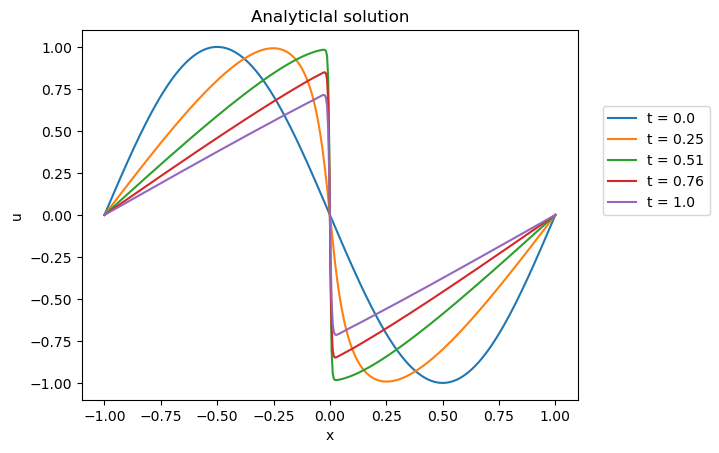

In [21]:
"""
Analytical solution via the Hopf-Cole Transformation and Gauss-Hermit Quadrature
"""

####################################################
# Parameters
####################################################

nu = 0.01/np.pi

x0 = -1.0
xL = 1.0

t0 = 0.0
tf = 1.0

Nx = 400
Nt = 100

x = np.linspace(x0, xL, Nx)
t = np.linspace(t0, tf, Nt)

####################################################
# Gauss-Hermite quadrature
####################################################

quad_order = 32

q, w = hermgauss(quad_order)

####################################################
# Analytical solution
####################################################

u_quad = np.zeros((Nx, Nt), dtype=np.float32)

for j in range(Nt):
    if t[j] == 0.0:
        u_quad[:, j] = -np.sin(np.pi*x)  ## initial condition
        continue

    c = 2*np.sqrt(nu*t[j])

    for i in range(Nx):
        numerator = 0.0
        denominator = 0.0
        for k in range(quad_order):
            xi = x[i] - c*q[k]
            weight = np.exp(-np.cos(np.pi*xi)/(2*np.pi*nu))
            numerator += (-w[k]* c* np.sin(np.pi*xi)* weight)
            denominator += (w[k]* c* weight)

        u_quad[i,j] = numerator/denominator

print('x.shape: ', x.shape)
print('t.shape: ', t.shape)
print('u_quad.shape: ', u_quad.shape)

####################################################
# Visualization of solution u(x,t)
####################################################

plt.plot(x,u_quad[:,0], label='t = '+str(round(t[0], 2)))
plt.plot(x,u_quad[:,25], label='t = '+str(round(t[25], 2)))
plt.plot(x,u_quad[:,50], label='t = '+str(round(t[50], 2)))
plt.plot(x,u_quad[:,75], label='t = '+str(round(t[75], 2)))
plt.plot(x,u_quad[:,99], label='t = '+str(round(t[99], 2)))

plt.title('Analyticlal solution')
plt.xlabel('x')
plt.ylabel('u')

plt.legend(loc=(1.05,0.5))
plt.show()

## Solution with PINN

In [3]:
"""
Neural Network
"""

class BurgersPINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        modules = []
        for i in range(len(layers)-2):
            modules.append(nn.Linear(layers[i], layers[i+1]))
            modules.append(nn.Tanh())

        modules.append(nn.Linear(layers[-2], layers[-1]))
        self.network = nn.Sequential(*modules)
        # train log(viscosity)
        self.log_nu = nn.Parameter(torch.tensor([-5.0], device=device))

    @property
    def nu(self):
        return torch.exp(self.log_nu)

    def forward(self,x):
        return self.network(x)
    
"""
Create model
"""
layers = [2,20,20,20,20,20,20,20,20,1]
model = BurgersPINN(layers).to(device)


In [4]:
"""
loss functions
"""

def PDE_loss():
    g = XT_pde.clone().detach().requires_grad_(True) ## XT_pde = (x,t)
    u = model(g)

    grad_u = torch.autograd.grad(u,g,grad_outputs=torch.ones_like(u),create_graph=True)[0]
    u_x = grad_u[:,0:1]
    u_t = grad_u[:,1:2]

    grad2 = torch.autograd.grad(u_x,g,grad_outputs=torch.ones_like(u_x),create_graph=True)[0]
    u_xx = grad2[:,0:1]

    residual = u_t + u*u_x - model.nu*u_xx
    return torch.mean(residual**2)

def Data_loss():
    pred = model(XT_u)
    return torch.mean((pred-U_u)**2)

def IC_loss():
    pred = model(XT_ic)
    return torch.mean((pred-U_ic)**2)

def BC_loss():
    left = model(XT_left)
    right = model(XT_right)
    return torch.mean(left**2)+torch.mean(right**2)

def Total_loss():
    lpde = PDE_loss()
    ldata = Data_loss()
    lic = IC_loss()
    lbc = BC_loss()
    total = lpde + ldata + lic + lbc
    return total

In [5]:
"""
preparing data
"""

x0 = -1.0
xL = 1.0

t0 = 0.0
tf = 1.0

##################################################################
# Collocation points : points at which pde loss are computed
##################################################################

Nf = 10000
sampler = LatinHypercube(d=2)
# Generate PDE collocation points using Latin Hypercube Sampling (LHS).
# LHS distributes points more uniformly over the space-time domain than
# purely random sampling, reducing clusters and empty regions. This helps
# the PINN enforce the PDE throughout the entire domain while retaining
# the benefits of random sampling.
X = sampler.random(Nf)
x_pde = x0 + (xL-x0)*X[:,0:1]
t_pde = t0 + (tf-t0)*X[:,1:2]
XT_pde = np.hstack((x_pde,t_pde))
XT_pde = torch.tensor(XT_pde,dtype=torch.float32,device=device)

##################################################################
# Initial Condition points : points at which IC loss are computed
##################################################################

Nic = 256
x_ic = np.linspace(x0,xL,Nic).reshape(-1,1)
t_ic = np.zeros_like(x_ic)
u_ic = -np.sin(np.pi*x_ic) ## initial condition
XT_ic = np.hstack((x_ic,t_ic))
XT_ic = torch.tensor(XT_ic,dtype=torch.float32,device=device)
U_ic = torch.tensor(u_ic,dtype=torch.float32,device=device)

##################################################################
# Boundary Condition points : points at which BC loss are computed
##################################################################

Nbc = 256
t_bc = np.linspace(t0,tf,Nbc).reshape(-1,1)
x_left = x0*np.ones_like(t_bc)
x_right = xL*np.ones_like(t_bc)
XT_left = np.hstack((x_left,t_bc))
XT_left = torch.tensor(XT_left,dtype=torch.float32,device=device)
XT_right = np.hstack((x_right,t_bc))
XT_right = torch.tensor(XT_right,dtype=torch.float32,device=device)

##################################################################
# Training Data : points at which traninng loss are computed
##################################################################

snap = np.array([0,0.125,0.25,0.375,0.5,0.625,0.75,0.875])
Nx = 128
Nt = len(snap)
x_sensor = x0 + (np.arange(Nx)+0.5)*(xL-x0)/Nx
t_sensor = snap

X, T = np.meshgrid(x_sensor,t_sensor,indexing="ij")
xs = X.reshape(-1,1)
ts = T.reshape(-1,1)
XT_u = np.hstack((xs,ts))
XT_u = torch.tensor(XT_u,dtype=torch.float32,device=device)

idx = np.floor(256*(xs-x0)/(xL-x0)).astype(int)
idt = np.floor(100*(ts-t0)/(tf-t0)).astype(int)
U_u = u_quad[idx,idt]  ## training data for u

sigma = 0.2
U_u += sigma*np.random.randn(*U_u.shape) ## adding some random data in order to add some noise
U_u = torch.tensor(U_u,dtype=torch.float32,device=device)

In [6]:
"""
Training using L-BFGS optimizer
"""

model.parameters() 
#There is only ONE optimizer. It optimizes every NN weight, every bias, 
# and viscosity because model.parameters() contains everything.


##################################################################
# Optimizer: L-BFGS
##################################################################

optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=10000,
    history_size=100,
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
    line_search_fn="strong_wolfe"
)

##################################################################
# Training Loop
##################################################################

# def closure():
#     optimizer.zero_grad()
#     loss = Total_loss()
#     loss.backward()
#     return loss

iteration = 0

loss_history = []
pde_history = []
ic_history = []
bc_history = []
data_history = []
nu_history = []

def closure():

    global iteration

    optimizer.zero_grad()

    lpde = PDE_loss()
    ldata = Data_loss()
    lic = IC_loss()
    lbc = BC_loss()

    loss = lpde + ldata + lic + lbc

    loss_history.append(loss.item())
    pde_history.append(lpde.item())
    ic_history.append(lic.item())
    bc_history.append(lbc.item())
    data_history.append(ldata.item())
    nu_history.append(model.nu.item())

    loss.backward()

    iteration += 1

    if iteration % 50 == 0:
        print(
            f"Iter {iteration:5d} | "
            f"Loss={loss.item():.3e} | "
            f"PDE={lpde.item():.3e} | "
            f"nu={model.nu.item():.6f}"
        )

    return loss

print("Training...")

final_loss = optimizer.step(closure)

print("Done.")

Training...
Iter    50 | Loss=7.396e-01 | PDE=1.305e-01 | nu=0.007701
Iter   100 | Loss=2.770e-01 | PDE=6.914e-02 | nu=0.019371
Iter   150 | Loss=1.402e-01 | PDE=2.555e-02 | nu=0.046242
Iter   200 | Loss=1.206e-01 | PDE=1.177e-02 | nu=0.060994
Iter   250 | Loss=1.078e-01 | PDE=1.305e-02 | nu=0.049131
Iter   300 | Loss=9.263e-02 | PDE=1.560e-02 | nu=0.046100
Iter   350 | Loss=7.777e-02 | PDE=1.187e-02 | nu=0.038626
Iter   400 | Loss=7.077e-02 | PDE=1.157e-02 | nu=0.031437
Iter   450 | Loss=6.723e-02 | PDE=9.958e-03 | nu=0.031927
Iter   500 | Loss=6.514e-02 | PDE=8.592e-03 | nu=0.031435
Iter   550 | Loss=6.359e-02 | PDE=8.539e-03 | nu=0.030094
Iter   600 | Loss=6.248e-02 | PDE=7.975e-03 | nu=0.030670
Iter   650 | Loss=6.024e-02 | PDE=8.041e-03 | nu=0.027673
Iter   700 | Loss=5.741e-02 | PDE=6.190e-03 | nu=0.026428
Iter   750 | Loss=5.602e-02 | PDE=6.011e-03 | nu=0.024882
Iter   800 | Loss=5.510e-02 | PDE=5.424e-03 | nu=0.023941
Iter   850 | Loss=5.386e-02 | PDE=5.116e-03 | nu=0.022137
It

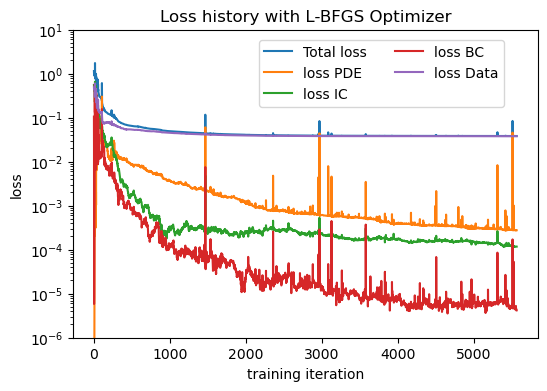

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.semilogy(loss_history, label="Total loss")
plt.semilogy(pde_history, label="loss PDE")
plt.semilogy(ic_history, label="loss IC")
plt.semilogy(bc_history, label="loss BC")
plt.semilogy(data_history, label="loss Data")

plt.xlabel("training iteration")
plt.title("Loss history with L-BFGS Optimizer")
plt.ylabel("loss")
plt.ylim(1e-6, 1e1)
# plt.grid(True)
plt.legend(loc=(0.4, 0.75), ncol=2)
plt.show()

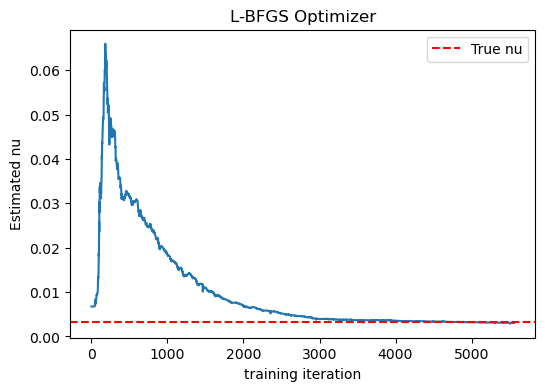

In [19]:
plt.figure(figsize=(6,4))
plt.plot(nu_history)
plt.axhline(nu, color='r', linestyle='--', label='True nu')
plt.ylabel("Estimated nu")
plt.xlabel("training iteration")
plt.title("L-BFGS Optimizer")
# plt.ylim(0,0.008)
plt.legend()
# plt.grid(True)
plt.show()

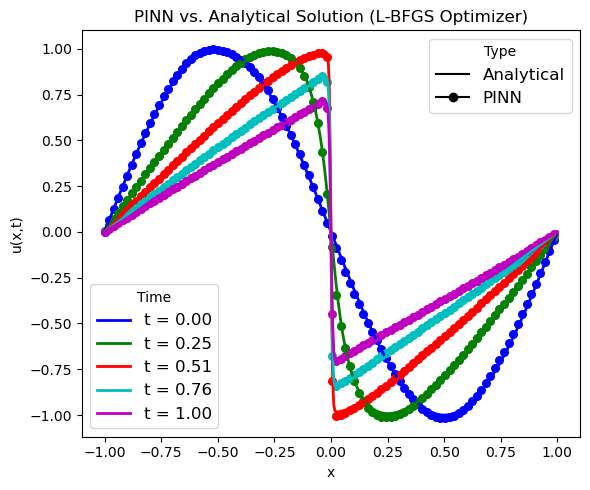

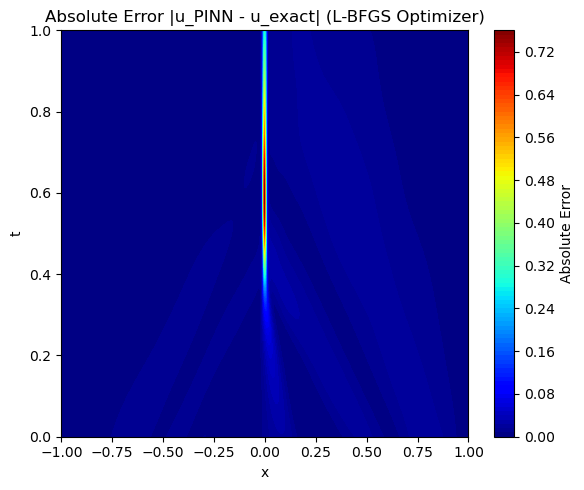

In [22]:
###############################################################
# Compare PINN prediction with analytical solution
###############################################################

model.eval()

# Evaluation grid
Nx_test = Nx
Nt_test = Nt

x = np.linspace(-1, 1, Nx_test)
t = np.linspace(0, 1, Nt_test)

# Meshgrid
X, T = np.meshgrid(x, t, indexing='ij')

# Convert to tensors
X_test = torch.tensor(X.reshape(-1,1), dtype=torch.float32, device=device)
T_test = torch.tensor(T.reshape(-1,1), dtype=torch.float32, device=device)

# Predict
with torch.no_grad():
    u_pred = model(torch.cat([X_test, T_test], dim=1))

u_pred = u_pred.cpu().numpy().reshape(Nx_test, Nt_test)

###############################################################
# Plot time snapshots
###############################################################

snapshot_indices = [0, 25, 50, 75, 99]
color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
plt.figure(figsize=(6,5))
for k,j in enumerate(snapshot_indices):
    plt.plot(x,u_quad[:,j],c=color_list[k],linewidth=2,label=f"t = {t[j]:.2f}")
    plt.scatter(x[::4],u_pred[::4,j],c=color_list[k],s=30)
leg_time = plt.legend(title="Time", loc='lower left',fontsize=12)
plt.gca().add_artist(leg_time)

sim_line = plt.plot([], [], 'k-', label='Analytical')[0]
ana_line = plt.plot([], [], c='k', marker='o', label='PINN')[0]
plt.legend(handles=[sim_line, ana_line], title="Type", loc='upper right',fontsize=12)
plt.ylabel("u(x,t)")
plt.title(f"PINN vs. Analytical Solution (L-BFGS Optimizer)")
plt.xlabel("x")
    # plt.grid(True)
plt.tight_layout()
plt.show()

###############################################################
# Evaluate Absoulute Error |u_PINN - u_exact|
###############################################################

error = np.abs(u_pred - u_quad)

plt.figure(figsize=(6,5))
plt.contourf(X,T,error,levels=100,cmap="jet")
plt.colorbar(label="Absolute Error")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Absolute Error |u_PINN - u_exact| (L-BFGS Optimizer)")
plt.tight_layout()
plt.show()

In [ ]:
"""
Training using ADAM optimizer
"""

model.parameters() 
#There is only ONE optimizer. It optimizes every NN weight, every bias, 
# and viscosity because model.parameters() contains everything.

##################################################################
# Optimizer: ADAM
##################################################################

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    betas=(0.99, 0.999)
)

##################################################################
# Training Loop
##################################################################

epochs = 12000

loss_history = []
pde_history = []
data_history = []
ic_history = []
bc_history = []
nu_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    lpde = PDE_loss()
    ldata = Data_loss()
    lic = IC_loss()
    lbc = BC_loss()

    loss = lpde + ldata + lic + lbc

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())
    pde_history.append(lpde.item())
    data_history.append(ldata.item())
    ic_history.append(lic.item())
    bc_history.append(lbc.item())
    nu_history.append(model.nu.item())

    if (epoch+1)%100==0:

        print(
            f"Epoch {epoch+1:5d} | "
            f"Loss={loss.item():.3e} | "
            f"PDE={lpde.item():.3e} | "
            f"nu={model.nu.item():.6f}"
        )

print("Done.")

Epoch   100 | Loss=9.855e-01 | PDE=1.521e-01 | nu=0.002944
Epoch   200 | Loss=7.453e-01 | PDE=5.707e-02 | nu=0.002910
Epoch   300 | Loss=5.960e-01 | PDE=5.141e-02 | nu=0.002896
Epoch   400 | Loss=5.023e-01 | PDE=8.041e-02 | nu=0.002893
Epoch   500 | Loss=4.226e-01 | PDE=8.484e-02 | nu=0.002897
Epoch   600 | Loss=3.680e-01 | PDE=9.926e-02 | nu=0.002911
Epoch   700 | Loss=3.356e-01 | PDE=1.035e-01 | nu=0.002934
Epoch   800 | Loss=3.157e-01 | PDE=9.921e-02 | nu=0.002964
Epoch   900 | Loss=3.018e-01 | PDE=9.653e-02 | nu=0.002997
Epoch  1000 | Loss=2.870e-01 | PDE=9.715e-02 | nu=0.003030
Epoch  1100 | Loss=2.699e-01 | PDE=9.245e-02 | nu=0.003067
Epoch  1200 | Loss=2.507e-01 | PDE=8.619e-02 | nu=0.003109
Epoch  1300 | Loss=2.307e-01 | PDE=8.220e-02 | nu=0.003157
Epoch  1400 | Loss=2.124e-01 | PDE=8.130e-02 | nu=0.003209
Epoch  1500 | Loss=1.963e-01 | PDE=7.929e-02 | nu=0.003260
Epoch  1600 | Loss=1.811e-01 | PDE=7.453e-02 | nu=0.003320
Epoch  1700 | Loss=1.660e-01 | PDE=6.895e-02 | nu=0.0034

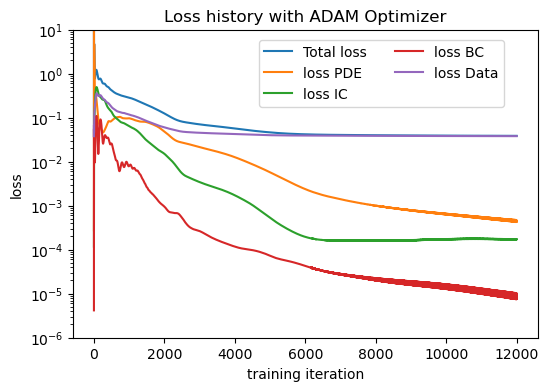

In [25]:
plt.figure(figsize=(6,4))
plt.semilogy(loss_history, label="Total loss")
plt.semilogy(pde_history, label="loss PDE")
plt.semilogy(ic_history, label="loss IC")
plt.semilogy(bc_history, label="loss BC")
plt.semilogy(data_history, label="loss Data")

plt.xlabel("training iteration")
plt.title("Loss history with ADAM Optimizer")
plt.ylabel("loss")
plt.ylim(1e-6, 1e1)
# plt.grid(True)
plt.legend(loc=(0.4, 0.75), ncol=2)
plt.show()

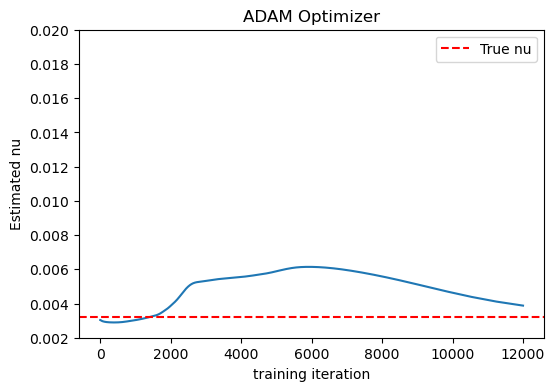

In [31]:
plt.figure(figsize=(6,4))
plt.plot(nu_history)
plt.axhline(nu, color='r', linestyle='--', label='True nu')
plt.ylabel("Estimated nu")
plt.xlabel("training iteration")
plt.title("ADAM Optimizer")
plt.ylim(0.002,0.02)
plt.legend()
# plt.grid(True)
plt.show()

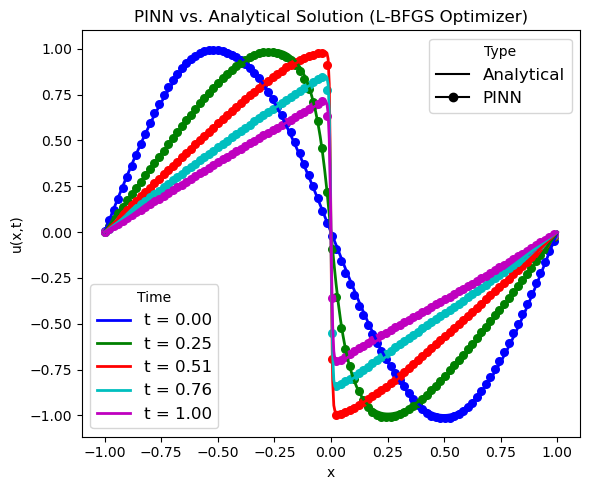

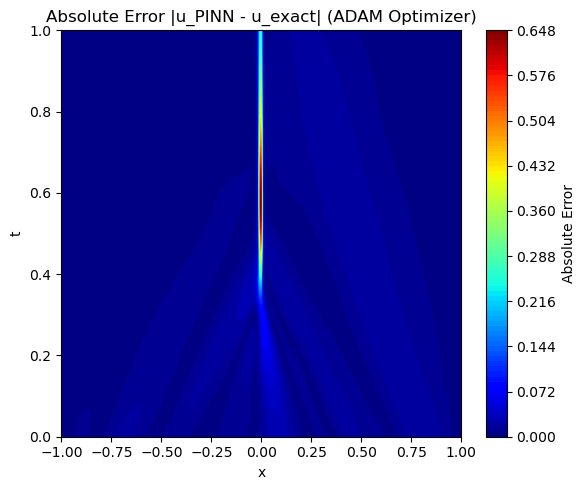

In [30]:
###############################################################
# Compare PINN prediction with analytical solution
###############################################################

model.eval()

# Evaluation grid
Nx_test = Nx
Nt_test = Nt

x = np.linspace(-1, 1, Nx_test)
t = np.linspace(0, 1, Nt_test)

# Meshgrid
X, T = np.meshgrid(x, t, indexing='ij')

# Convert to tensors
X_test = torch.tensor(X.reshape(-1,1), dtype=torch.float32, device=device)
T_test = torch.tensor(T.reshape(-1,1), dtype=torch.float32, device=device)

# Predict
with torch.no_grad():
    u_pred = model(torch.cat([X_test, T_test], dim=1))

u_pred = u_pred.cpu().numpy().reshape(Nx_test, Nt_test)

###############################################################
# Plot time snapshots
###############################################################

snapshot_indices = [0, 25, 50, 75, 99]
color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
plt.figure(figsize=(6,5))
for k,j in enumerate(snapshot_indices):
    plt.plot(x,u_quad[:,j],c=color_list[k],linewidth=2,label=f"t = {t[j]:.2f}")
    plt.scatter(x[::4],u_pred[::4,j],c=color_list[k],s=30)
leg_time = plt.legend(title="Time", loc='lower left',fontsize=12)
plt.gca().add_artist(leg_time)

sim_line = plt.plot([], [], 'k-', label='Analytical')[0]
ana_line = plt.plot([], [], c='k', marker='o', label='PINN')[0]
plt.legend(handles=[sim_line, ana_line], title="Type", loc='upper right',fontsize=12)
plt.ylabel("u(x,t)")
plt.title(f"PINN vs. Analytical Solution (L-BFGS Optimizer)")
plt.xlabel("x")
    # plt.grid(True)
plt.tight_layout()
plt.show()

###############################################################
# Evaluate Absoulute Error |u_PINN - u_exact|
###############################################################

error = np.abs(u_pred - u_quad)

plt.figure(figsize=(6,5))
plt.contourf(X,T,error,levels=100,cmap="jet")
plt.colorbar(label="Absolute Error")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Absolute Error |u_PINN - u_exact| (ADAM Optimizer)")
plt.tight_layout()
plt.show()